# 🚰 SHARP-Net v2 — Sewer & Culvert Pipe Defect Detection
### Fixed: Real-world CCTV image domain, improved sensitivity, better training

**Key fixes over v1:**
- Synthetic images now closely match real CCTV sewer footage (dark tunnel, perspective, lighting)
- Focal loss added to handle class imbalance (defects are small)
- Lower inference threshold + test-time enhancement
- Contour-based defect highlighting with severity labels
- Edge-detection fusion for more sensitive defect localization

> **Runtime:** Set to T4 GPU → Runtime > Change Runtime Type > GPU

## 📦 Cell 1: Install & Imports

In [1]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
pip('tensorflow') # Changed from tensorflow==2.13.0
pip('opencv-python-headless')
pip('albumentations==1.3.1')
pip('scikit-learn')
pip('tqdm')
print('✅ Dependencies ready')

✅ Dependencies ready


In [2]:
# ============================================================
# CELL 2: Imports & global config
# ============================================================
import os, glob, random, warnings, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

gpus = tf.config.list_physical_devices('GPU')
print(f'TF {tf.__version__} | GPU: {gpus}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Config ─────────────────────────────────────────────────
IMG_H, IMG_W = 256, 256
BATCH_SIZE   = 8
EPOCHS       = 50
LR           = 1e-3

BASE_DIR  = '/content'
DATA_DIR  = f'{BASE_DIR}/dataset'
IMG_DIR   = f'{DATA_DIR}/images'
MASK_DIR  = f'{DATA_DIR}/masks'
CKPT_DIR  = f'{BASE_DIR}/checkpoints'
LOG_DIR   = f'{BASE_DIR}/logs'

for d in [IMG_DIR, MASK_DIR, CKPT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
print('📁 Directories ready')

TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
📁 Directories ready


## 🎨 Cell 3: Realistic CCTV-Style Synthetic Dataset Generator

In [3]:
import os, glob, random, warnings, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

gpus = tf.config.list_physical_devices('GPU')
print(f'TF {tf.__version__} | GPU: {gpus}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Config ─────────────────────────────────────────────────
IMG_H, IMG_W = 256, 256
BATCH_SIZE   = 8
EPOCHS       = 50
LR           = 1e-3

BASE_DIR  = '/content'
DATA_DIR  = f'{BASE_DIR}/dataset'
IMG_DIR   = f'{DATA_DIR}/images'
MASK_DIR  = f'{DATA_DIR}/masks'
CKPT_DIR  = f'{BASE_DIR}/checkpoints'
LOG_DIR   = f'{BASE_DIR}/logs'

for d in [IMG_DIR, MASK_DIR, CKPT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
print('📁 Directories ready')

def make_cctv_background(h, w):
    """
    Generate a realistic CCTV sewer pipe interior background.
    Mimics the dark tunnel + spotlight look of real inspection footage.
    """
    img = np.zeros((h, w, 3), dtype=np.uint8)
    cx, cy = w//2 + random.randint(-10,10), h//2 + random.randint(-10,10)
    radius = int(min(h,w)*0.42) + random.randint(-8,8)

    # ── Outer background: near-black ──
    bg_val = random.randint(5, 20)
    img[:] = bg_val

    # ── Pipe interior base: dark concrete grey ──
    pipe_mask = np.zeros((h,w), dtype=np.uint8)
    cv2.circle(pipe_mask, (cx,cy), radius, 255, -1)

    # Base concrete color (brownish grey, slightly warm)
    base_b = random.randint(55, 85)
    base_g = random.randint(60, 90)
    base_r = random.randint(65, 95)
    for c, val in enumerate([base_b, base_g, base_r]):
        img[:,:,c] = np.where(pipe_mask>0, val, img[:,:,c])

    # ── Concrete texture: random small variations ──
    texture = np.random.randint(-18, 18, (h,w,3), dtype=np.int16)
    img = np.clip(img.astype(np.int16) + texture * (pipe_mask[:,:,None]>0), 0, 255).astype(np.uint8)

    # ── Spotlight illumination: bright center, dark edges ──
    # Real CCTV cameras have a central light source
    light_cx = cx + random.randint(-15, 15)
    light_cy = cy + random.randint(-20, 10)
    Y, X = np.ogrid[:h, :w]
    dist_sq = ((X - light_cx)**2 + (Y - light_cy)**2).astype(np.float32)
    sigma = (radius * 0.85)**2
    spotlight = np.exp(-dist_sq / sigma)
    spotlight = (spotlight * 110).astype(np.int16)
    for c in range(3):
        img[:,:,c] = np.clip(
            img[:,:,c].astype(np.int16) + spotlight * (pipe_mask>0), 0, 200
        ).astype(np.uint8)

    # ── Vignette: darker at pipe wall ──
    dist_from_center = np.sqrt((X-cx)**2 + (Y-cy)**2).astype(np.float32)
    vignette = np.clip(1.0 - (dist_from_center / radius)**2.5, 0, 1)
    for c in range(3):
        img[:,:,c] = (img[:,:,c].astype(np.float32) * vignette).astype(np.uint8)

    # ── Pipe ring / joint lines ──
    ring_col = max(0, base_b - 30)
    cv2.circle(img, (cx,cy), radius,   (ring_col, ring_col, ring_col+5), 5)
    cv2.circle(img, (cx,cy), radius-2, (ring_col-10,)*3, 2)

    # ── Horizontal joint line (pipe section boundary) ──
    if random.random() > 0.5:
        jy = cy + random.randint(-radius//3, radius//3)
        x1 = max(0, cx - int(np.sqrt(max(0, radius**2 - (jy-cy)**2))))
        x2 = min(w, cx + int(np.sqrt(max(0, radius**2 - (jy-cy)**2))))
        cv2.line(img, (x1,jy), (x2,jy), (ring_col-15,)*3, random.randint(2,5))

    # ── Water at invert (bottom of pipe) ──
    if random.random() > 0.35:
        wy   = cy + int(radius * random.uniform(0.45, 0.75))
        wr   = int(np.sqrt(max(0, radius**2 - (wy-cy)**2)) * random.uniform(0.6,0.95))
        pts  = np.array([[cx-wr, wy],[cx+wr, wy],[cx+wr, cy+radius],[cx-wr, cy+radius]])
        cv2.fillPoly(img, [pts],
            (random.randint(20,45), random.randint(35,65), random.randint(50,85)))
        # Water surface ripple
        cv2.ellipse(img, (cx, wy), (wr, random.randint(3,7)), 0, 0, 180,
            (random.randint(35,60), random.randint(55,85), random.randint(75,110)), 2)

    # ── Sediment / silt at bottom ──
    if random.random() > 0.4:
        sy = cy + int(radius * random.uniform(0.5, 0.8))
        sr = int(np.sqrt(max(0, radius**2 - (sy-cy)**2)) * random.uniform(0.5,0.9))
        if sr > 5:
            pts2 = np.array([[cx-sr, sy],[cx+sr, sy],[cx+sr,cy+radius],[cx-sr,cy+radius]])
            silt_col = (random.randint(55,85), random.randint(50,75), random.randint(40,65))
            cv2.fillPoly(img, [pts2], silt_col)

    # ── Final noise ──
    noise = np.random.normal(0, 6, img.shape).astype(np.int16)
    img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img, pipe_mask, cx, cy, radius


def add_defect(img, defect_mask, cx, cy, radius, dtype):
    """
    Add a realistic defect to the pipe image and update the binary mask.
    All defects are drawn to closely match real CCTV sewer inspection images.
    """
    h, w = img.shape[:2]
    dm = np.zeros((h, w), dtype=np.uint8)

    # ── Pipe region mask (only draw defects inside pipe) ──
    pipe_rgn = np.zeros((h,w), dtype=np.uint8)
    cv2.circle(pipe_rgn, (cx,cy), radius-8, 255, -1)

    if dtype == 'longitudinal_crack':
        # Long crack running along pipe axis
        start_angle = random.uniform(0, 2*np.pi)
        r0 = random.randint(radius//3, radius-20)
        x0 = int(cx + r0*np.cos(start_angle))
        y0 = int(cy + r0*np.sin(start_angle))
        x0, y0 = np.clip(x0,5,w-5), np.clip(y0,5,h-5)
        length = random.randint(50, 100)
        angle  = start_angle + random.uniform(-0.3, 0.3)
        pts    = [(x0,y0)]
        for _ in range(length):
            angle += random.gauss(0, 0.12)
            nx = int(pts[-1][0] + np.cos(angle))
            ny = int(pts[-1][1] + np.sin(angle))
            nx,ny = np.clip(nx,0,w-1), np.clip(ny,0,h-1)
            pts.append((nx,ny))
        # Draw crack: dark line with lighter edges (realistic)
        for i in range(1,len(pts)):
            w_crack = random.randint(1,3)
            dark  = max(0, int(img[pts[i][1],pts[i][0],0])-40)
            cv2.line(img,   pts[i-1], pts[i], (dark,dark,dark+5), w_crack+1)
            cv2.line(dm,    pts[i-1], pts[i], 255, w_crack+4)

    elif dtype == 'circumferential_crack':
        # Crack going around the pipe circumference
        arc_r     = random.randint(radius//2, radius-15)
        arc_start = random.randint(0, 360)
        arc_len   = random.randint(40, 130)
        for seg in range(0, arc_len, 3):
            a1 = arc_start + seg
            a2 = a1 + 3 + random.randint(0,2)
            r_jit = arc_r + random.randint(-4, 4)
            dark = int(max(0, int(img[cy, cx, 0]) - 35)) # Explicitly cast dark to int
            cv2.ellipse(img, (cx,cy), (r_jit, r_jit), 0, a1, a2,
                        (int(dark), int(dark), int(dark)+5), random.randint(1,3)) # Explicitly cast color tuple elements
            cv2.ellipse(dm, (cx,cy), (r_jit, r_jit), 0, a1, a2, 255, 7)

    elif dtype == 'root':
        # Root intrusion: dark branching tendrils from pipe wall
        entry_angle = random.uniform(0, 2*np.pi)
        ex = int(cx + (radius-12)*np.cos(entry_angle))
        ey = int(cy + (radius-12)*np.sin(entry_angle))
        ex, ey = np.clip(ex,5,w-5), np.clip(ey,5,h-5)
        # Main root toward center
        for branch in range(random.randint(3,8)):
            ba = entry_angle + np.pi + random.gauss(0, 0.5)
            bl = random.randint(20, 60)
            bpts = [(ex,ey)]
            for _ in range(bl):
                ba += random.gauss(0, 0.12)
                nx = int(bpts[-1][0] + np.cos(ba))
                ny = int(bpts[-1][1] + np.sin(ba))
                nx,ny = np.clip(nx,0,w-1), np.clip(ny,0,h-1)
                bpts.append((nx,ny))
            thick = random.randint(2,5)
            col   = (random.randint(15,40), random.randint(25,55), random.randint(10,30))
            for i in range(1,len(bpts)):
                cv2.line(img, bpts[i-1], bpts[i], col, thick)
                cv2.line(dm,  bpts[i-1], bpts[i], 255, thick+5)

    elif dtype == 'hole':
        # Hole / perforation
        angle = random.uniform(0, 2*np.pi)
        hr    = random.randint(radius//4, radius-20)
        hx    = int(cx + hr*np.cos(angle))
        hy    = int(cy + hr*np.sin(angle))
        hx,hy = np.clip(hx,8,w-8), np.clip(hy,8,h-8)
        hole_r = random.randint(7, 20)
        # Very dark hole center
        cv2.circle(img, (hx,hy), hole_r,   (5,  5,  5),  -1)
        # Slightly lighter ring around hole (crushed pipe material)
        cv2.circle(img, (hx,hy), hole_r+3, (40, 38, 35),  3)
        cv2.circle(dm,  (hx,hy), hole_r+5, 255, -1)

    elif dtype == 'deposit':
        # Encrustation / mineral deposit: lighter, rough patch on wall
        da    = random.uniform(0, 2*np.pi)
        dr    = random.randint(radius//3, radius-15)
        dx    = int(cx + dr*np.cos(da))
        dy    = int(cy + dr*np.sin(da))
        dx,dy = np.clip(dx,10,w-10), np.clip(dy,10,h-10)
        poly  = []
        for p in range(random.randint(6,10)):
            pa  = p * 2*np.pi/10 + random.gauss(0,0.3)
            pr  = random.randint(10,28)
            poly.append([int(dx+pr*np.cos(pa)), int(dy+pr*np.sin(pa))])
        poly = np.array(poly, dtype=np.int32)
        base = img[np.clip(dy,0,h-1), np.clip(dx,0,w-1), 0]
        dep_col = (min(255,int(base)+45), min(255,int(base)+38), min(255,int(base)+25))
        cv2.fillPoly(img, [poly], dep_col)
        # Rough edge texture
        for _ in range(10):
            pt = poly[random.randint(0,len(poly)-1)]
            cv2.circle(img, tuple(pt), random.randint(2,5),
                       (dep_col[0]-15, dep_col[1]-12, dep_col[2]-10), -1)
        cv2.fillPoly(dm, [poly], 255)

    elif dtype == 'deformation':
        # Pipe wall deformation: visible inward collapse
        da     = random.uniform(0, 2*np.pi)
        arc_s  = int(np.degrees(da))
        arc_e  = arc_s + random.randint(25, 80)
        r_def  = radius - random.randint(12, 28)
        base   = img[cy, cx, 0]
        for dr in range(0, 14, 2):
            shade = max(5, base - dr*4)
            cv2.ellipse(img, (cx,cy), (r_def+dr, r_def+dr),
                        0, arc_s, arc_e, (int(shade),int(shade),int(shade)+3), 3)
        cv2.ellipse(dm, (cx,cy), (r_def+7, r_def+7), 0, arc_s, arc_e, 255, 22)

    elif dtype == 'joint_offset':
        # Offset pipe joint: visible step/ledge
        jy = cy + random.randint(-radius//2, radius//2)
        x1 = max(0, cx - int(np.sqrt(max(0, radius**2-(jy-cy)**2))))
        x2 = min(w, cx + int(np.sqrt(max(0, radius**2-(jy-cy)**2))))
        offset  = random.randint(4, 12)
        base    = img[np.clip(jy,0,h-1), cx, 0]
        cv2.line(img, (x1, jy), (x2, jy), (int(max(0,base-50)),)*3, random.randint(3,7))
        cv2.line(img, (x1, jy+offset), (x2, jy+offset),
                 (int(min(255,base+30)),)*3, random.randint(2,4))
        cv2.line(dm, (x1, jy), (x2, jy), 255, 14)
        cv2.line(dm, (x1, jy+offset), (x2, jy+offset), 255, 10)

    # ── Clip defect mask to inside pipe only ──
    dm = cv2.bitwise_and(dm, pipe_rgn)
    defect_mask[dm > 0] = 1
    return img, defect_mask


def generate_sample(idx, img_dir, mask_dir, size=256):
    img, pipe_mask, cx, cy, radius = make_cctv_background(size, size)
    defect_mask = np.zeros((size, size), dtype=np.uint8)

    DEFECT_TYPES = [
        'longitudinal_crack', 'circumferential_crack',
        'root', 'hole', 'deposit', 'deformation', 'joint_offset'
    ]
    # Force at least 1 defect, up to 3
    n_def  = random.choices([1,2,3], weights=[0.4,0.4,0.2])[0]
    chosen = random.sample(DEFECT_TYPES, min(n_def, len(DEFECT_TYPES)))
    for dt in chosen:
        img, defect_mask = add_defect(img, defect_mask, cx, cy, radius, dt)

    cv2.imwrite(os.path.join(img_dir,  f's{idx:04d}.png'), img)
    cv2.imwrite(os.path.join(mask_dir, f's{idx:04d}.png'),
                (defect_mask * 255).astype(np.uint8))


N = 500
print(f'🔧 Generating {N} CCTV-realistic sewer pipe images ...')
for i in tqdm(range(N)):
    generate_sample(i, IMG_DIR, MASK_DIR)

all_imgs  = sorted(glob.glob(f'{IMG_DIR}/*.png'))
all_masks = sorted(glob.glob(f'{MASK_DIR}/*.png'))
print(f'✅ {len(all_imgs)} images, {len(all_masks)} masks generated')

TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
📁 Directories ready
🔧 Generating 500 CCTV-realistic sewer pipe images ...


100%|██████████| 500/500 [00:20<00:00, 24.81it/s]

✅ 500 images, 500 masks generated


## 🔍 Cell 4: Visualize Dataset

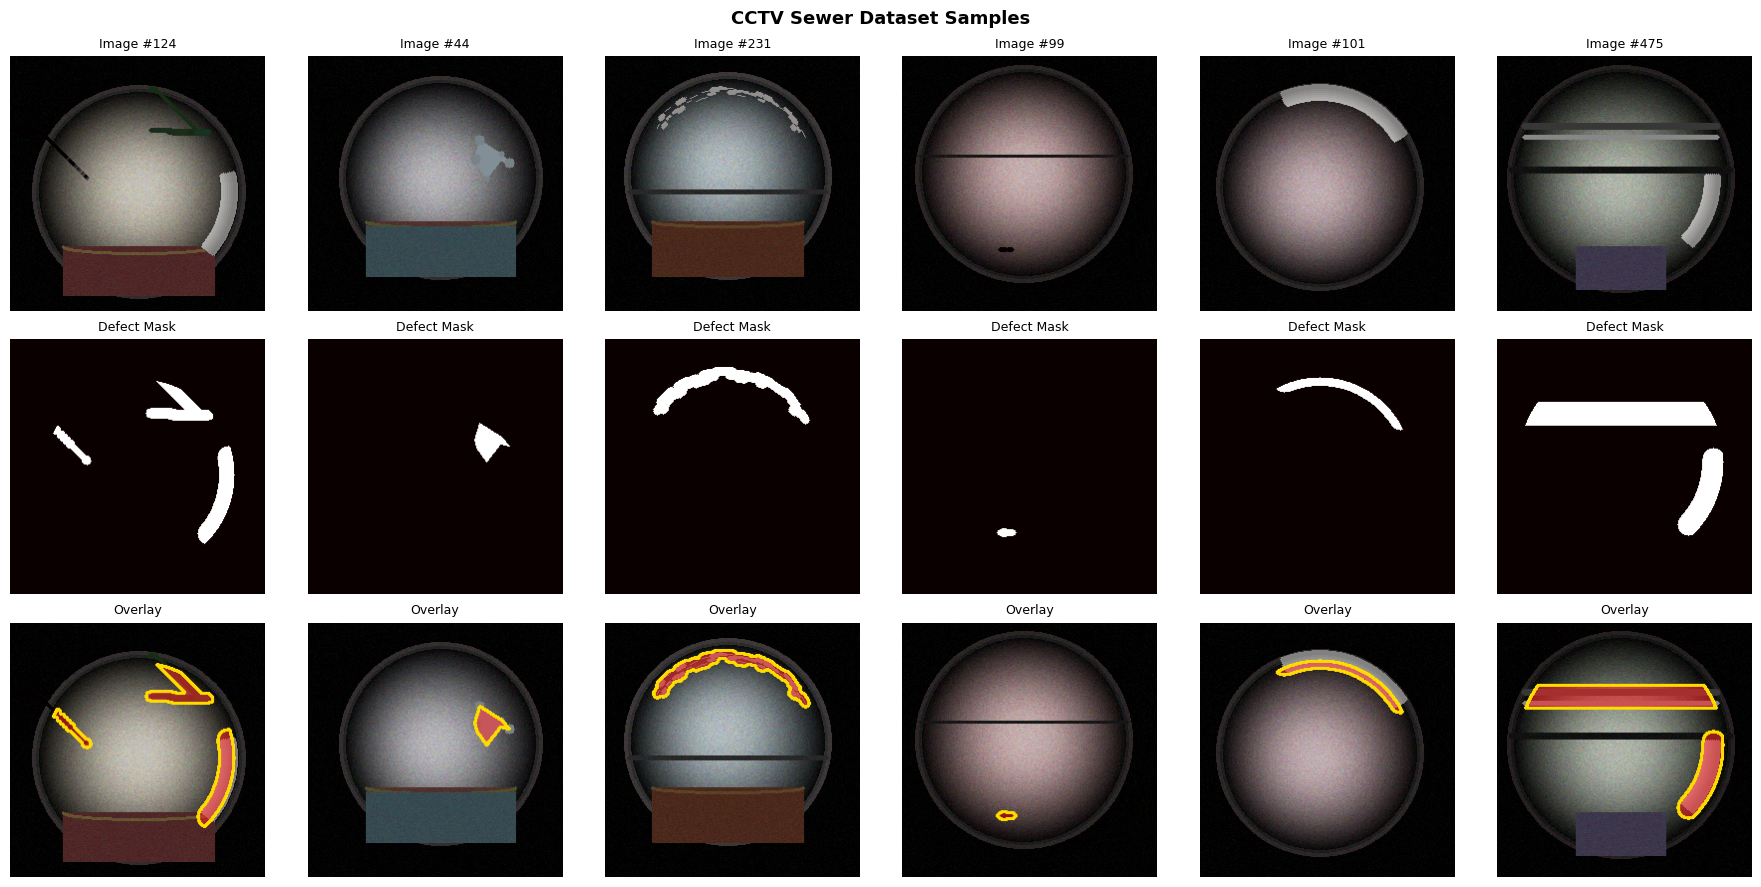

📊 Defect pixel ratio: 4.0%


In [4]:
# ============================================================
# CELL 4: Visualize samples
# ============================================================
N_SHOW = 6
idxs   = random.sample(range(len(all_imgs)), N_SHOW)

fig, axes = plt.subplots(3, N_SHOW, figsize=(N_SHOW*3, 9))
fig.suptitle('CCTV Sewer Dataset Samples', fontsize=13, fontweight='bold')

for col, i in enumerate(idxs):
    img  = cv2.cvtColor(cv2.imread(all_imgs[i]),  cv2.COLOR_BGR2RGB)
    mask = cv2.imread(all_masks[i], cv2.IMREAD_GRAYSCALE)

    overlay = img.copy().astype(np.float32)
    dp      = mask > 127
    overlay[dp] = overlay[dp]*0.45 + np.array([255,40,40])*0.55
    overlay = overlay.astype(np.uint8)
    cnts,_  = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cnts, -1, (255,220,0), 2)

    axes[0,col].imshow(img);     axes[0,col].set_title(f'Image #{i}', fontsize=9)
    axes[1,col].imshow(mask, cmap='hot'); axes[1,col].set_title('Defect Mask', fontsize=9)
    axes[2,col].imshow(overlay); axes[2,col].set_title('Overlay', fontsize=9)
    for r in range(3): axes[r,col].axis('off')

axes[0,0].set_ylabel('Input',   fontsize=10, fontweight='bold', rotation=0, ha='right')
axes[1,0].set_ylabel('Mask',    fontsize=10, fontweight='bold', rotation=0, ha='right')
axes[2,0].set_ylabel('Overlay', fontsize=10, fontweight='bold', rotation=0, ha='right')
plt.tight_layout()
plt.savefig('/content/dataset_preview.png', dpi=120, bbox_inches='tight')
plt.show()

# Class balance
total_px, defect_px = 0, 0
for mp in random.sample(all_masks, 100):
    m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    total_px  += m.size
    defect_px += (m > 127).sum()
print(f'📊 Defect pixel ratio: {defect_px/total_px*100:.1f}%')

## ✂️ Cell 5: Data Pipeline

In [5]:
# ============================================================
# CELL 5: Split + augmented tf.data pipeline
# ============================================================
pairs = list(zip(all_imgs, all_masks))
random.shuffle(pairs)
ims, ms = zip(*pairs)
ims, ms = list(ims), list(ms)
n = len(ims)
ntr, nv = int(0.70*n), int(0.15*n)

tr_i, tr_m  = ims[:ntr],        ms[:ntr]
va_i, va_m  = ims[ntr:ntr+nv],  ms[ntr:ntr+nv]
te_i, te_m  = ims[ntr+nv:],     ms[ntr+nv:]
print(f'Split → Train:{len(tr_i)} Val:{len(va_i)} Test:{len(te_i)}')

def load_pair(ip, mp):
    img  = tf.image.decode_png(tf.io.read_file(ip), 3)
    img  = tf.image.resize(img, [IMG_H,IMG_W])
    img  = tf.cast(img, tf.float32) / 255.0
    mask = tf.image.decode_png(tf.io.read_file(mp), 1)
    mask = tf.image.resize(mask, [IMG_H,IMG_W], method='nearest')
    mask = tf.cast(mask > 127, tf.float32)
    return img, mask

@tf.function
def augment_pair(img, mask):
    # Flip
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    # Rotation (90°)
    k = tf.random.uniform((), 0, 4, dtype=tf.int32)
    img  = tf.image.rot90(img,  k)
    mask = tf.image.rot90(mask, k)
    # Colour jitter (image only)
    img = tf.image.random_brightness(img, 0.20)
    img = tf.image.random_contrast(img, 0.80, 1.20)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

def make_ds(ip, mp, aug=False, bs=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((ip, mp))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if aug:
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(tr_i, tr_m, aug=True)
val_ds   = make_ds(va_i, va_m)
test_ds  = make_ds(te_i, te_m, bs=1)

for xb, yb in train_ds.take(1):
    print(f'Batch check → img:{xb.shape} mask:{yb.shape}')
print('✅ Data pipeline ready')

Split → Train:350 Val:75 Test:75
Batch check → img:(8, 256, 256, 3) mask:(8, 256, 256, 1)
✅ Data pipeline ready


## 🧠 Cell 6: SHARP-Net Architecture

In [6]:
# ============================================================
# CELL 6: Full SHARP-Net architecture
#
# Bottom-Up:  Inception-like blocks (3×3 + 5×5 depthwise sep
#             convs + parallel max-pool) — Section III-A
# Top-Down:   FPN-style (upsample + lateral + 3×3 sep conv)
# Haar Gate:  Injected at layer 2 of bottom-up — Section III-C
# Classifier: Shared 128-dim output maps
# ============================================================

class HaarGate(layers.Layer):
    """
    Feature Injection Gate for Haar-like features.
    Initialises with 8 Haar templates (edge/line/diagonal/corner),
    learns to gate the incoming feature map element-wise.
    """
    TEMPLATES = [
        [[ 1, 1, 1],[ 0, 0, 0],[-1,-1,-1]],   # H-edge
        [[ 1, 0,-1],[ 1, 0,-1],[ 1, 0,-1]],   # V-edge
        [[ 1, 0,-1],[ 0, 0, 0],[-1, 0, 1]],   # Diag ↗
        [[-1, 0, 1],[ 0, 0, 0],[ 1, 0,-1]],   # Diag ↘
        [[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]],   # Laplacian
        [[-1,-1,-1],[ 2, 2, 2],[-1,-1,-1]],   # H-line
        [[-1, 2,-1],[-1, 2,-1],[-1, 2,-1]],   # V-line
        [[ 1, 1, 0],[ 1, 0,-1],[ 0,-1,-1]],   # Corner
    ]
    def __init__(self, n_filters=16, **kw):
        super().__init__(**kw)
        self.n_filters = n_filters

    def build(self, input_shape):
        in_ch = input_shape[-1]
        n_t   = len(self.TEMPLATES)
        k_init= np.zeros((3,3,in_ch,self.n_filters), np.float32)
        for f in range(self.n_filters):
            t = np.array(self.TEMPLATES[f % n_t], np.float32) / 8.0
            for c in range(in_ch):
                k_init[:,:,c,f] = t
        self.haar = layers.Conv2D(self.n_filters, 3, padding='same', use_bias=False,
                                  kernel_initializer=tf.constant_initializer(k_init))
        self.gate = layers.Conv2D(in_ch, 1, padding='same', activation='sigmoid')
        self.bn   = layers.BatchNormalization()
        super().build(input_shape)

    def call(self, x, training=False):
        h = tf.nn.relu(self.bn(self.haar(x), training=training))
        g = self.gate(x)
        return x * g


def dws(x, filters, k=3, strides=1, name=None):
    """Depthwise-separable conv block."""
    pref = f'{name}_' if name else ''
    x = layers.DepthwiseConv2D(k, strides=strides, padding='same',
                                use_bias=False, name=f'{pref}dw')(x)
    x = layers.BatchNormalization(name=f'{pref}bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False,
                      name=f'{pref}pw')(x)
    x = layers.BatchNormalization(name=f'{pref}bn2')(x)
    x = layers.Activation('relu')(x)
    return x


def inception_block(x, filters, pfx='inc'):
    """Inception-like block with 3×3, 5×5 dws convs + max-pool branch."""
    f = max(filters // 4, 8)
    b1 = layers.Conv2D(f, 1, padding='same', use_bias=False, name=f'{pfx}_1x1')(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.Activation('relu')(b1)
    b2 = dws(x, f, k=3, name=f'{pfx}_3x3')
    b3 = dws(dws(x, f, k=3, name=f'{pfx}_5x5a'), f, k=3, name=f'{pfx}_5x5b')
    b4 = layers.MaxPooling2D(3, strides=1, padding='same', name=f'{pfx}_mp')(x)
    b4 = layers.Conv2D(f, 1, padding='same', use_bias=False, name=f'{pfx}_mpconv')(b4)
    b4 = layers.BatchNormalization()(b4); b4 = layers.Activation('relu')(b4)
    return layers.Concatenate(name=f'{pfx}_cat')([b1, b2, b3, b4])


def build_sharpnet(h=IMG_H, w=IMG_W):
    inp = keras.Input((h, w, 3), name='img')

    # ── STEM ──────────────────────────────────────────────
    s = layers.Conv2D(32, 3, padding='same', use_bias=False, name='stem')(inp)
    s = layers.BatchNormalization(name='stem_bn')(s)
    s = layers.Activation('relu')(s)

    # ── HAAR GATE (injected at layer 2 as per paper) ──────
    s = HaarGate(16, name='haar_gate')(s)

    # ── BOTTOM-UP ─────────────────────────────────────────
    c2 = inception_block(s,         64,  pfx='c2')          # 256×256
    p2 = layers.MaxPooling2D(2, 2, name='p2_dn')(c2)        # 128×128

    c3 = inception_block(p2,        128, pfx='c3')          # 128×128
    p3 = layers.MaxPooling2D(2, 2, name='p3_dn')(c3)        # 64×64

    c4 = inception_block(p3,        256, pfx='c4')          # 64×64
    p4 = layers.MaxPooling2D(2, 2, name='p4_dn')(c4)        # 32×32

    c5 = inception_block(p4,        256, pfx='c5')          # 32×32 (bottleneck)

    # ── TOP-DOWN FPN ──────────────────────────────────────
    # P5 reduce to 128
    t5 = layers.Conv2D(128, 1, padding='same', use_bias=False, name='t5_lat')(c5)
    t5 = layers.BatchNormalization()(t5); t5 = layers.Activation('relu')(t5)

    # P5 → P4
    t5_up = layers.UpSampling2D(2, interpolation='bilinear', name='up54')(t5)
    l4    = layers.Conv2D(128, 1, padding='same', use_bias=False, name='lat4')(c4)
    t4    = dws(layers.Add(name='add4')([t5_up, l4]), 128, name='td4')

    # P4 → P3
    t4_up = layers.UpSampling2D(2, interpolation='bilinear', name='up43')(t4)
    l3    = layers.Conv2D(128, 1, padding='same', use_bias=False, name='lat3')(c3)
    t3    = dws(layers.Add(name='add3')([t4_up, l3]), 128, name='td3')

    # P3 → P2
    t3_up = layers.UpSampling2D(2, interpolation='bilinear', name='up32')(t3)
    l2    = layers.Conv2D(128, 1, padding='same', use_bias=False, name='lat2')(c2)
    t2    = dws(layers.Add(name='add2')([t3_up, l2]), 128, name='td2')

    # ── FINAL OUTPUT (t2 is already at IMG_H, IMG_W resolution) ─────────────────
    out   = dws(t2, 64, name='head') # Use t2 directly
    out   = layers.Conv2D(1, 1, padding='same', activation='sigmoid', name='mask')(out)

    return Model(inp, out, name='SHARP_Net_v2')


model = build_sharpnet()
print(f'✅ SHARP-Net built — {model.count_params():,} parameters')
model.summary(line_length=80)

✅ SHARP-Net built — 299,505 parameters


Model: "SHARP_Net_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)      │ (None, 256, 256,  │           0 │ -                  │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem (Conv2D)         │ (None, 256, 256,  │         864 │ img[0][0]          │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_bn               │ (None, 256, 256,  │         128 │ stem[0][0]         │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 256, 256,  │           0 │ stem_bn[0][0]      │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ haar_gate (HaarGate)  │ (None, 256, 256,  │       5,728 │ activation[0][0]   │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5a_dw            │ (None, 256, 256,  │         288 │ haar_gate[0][0]    │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5a_bn1           │ (None, 256, 256,  │         128 │ c2_5x5a_dw[0][0]   │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_4          │ (None, 256, 256,  │           0 │ c2_5x5a_bn1[0][0]  │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5a_pw (Conv2D)   │ (None, 256, 256,  │         512 │ activation_4[0][0] │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5a_bn2           │ (None, 256, 256,  │          64 │ c2_5x5a_pw[0][0]   │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_5          │ (None, 256, 256,  │           0 │ c2_5x5a_bn2[0][0]  │
│ (Activation)          │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_3x3_dw             │ (None, 256, 256,  │         288 │ haar_gate[0][0]    │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5b_dw            │ (None, 256, 256,  │         144 │ activation_5[0][0] │
│ (DepthwiseConv2D)     │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_3x3_bn1            │ (None, 256, 256,  │         128 │ c2_3x3_dw[0][0]    │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ c2_5x5b_bn1           │ (None, 256, 256,  │          64 │ c2_5x5b_dw[0][0]   │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 256, 256,  │           0 │ c2_3x3_bn1[0][0]   │
│ (Activation)          │ 32)  

 Total params: 299,505 (1.14 MB)

 Trainable params: 293,201 (1.12 MB)

 Non-trainable params: 6,304 (24.62 KB)

## 📏 Cell 7: Loss & Metrics (Focal + Dice)

In [7]:
# ============================================================
# CELL 7: Loss functions + metrics
#
# Uses Focal loss (handles class imbalance — defects are small)
# combined with Dice loss (robust shape overlap metric).
# ============================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.75, eps=1e-6):
    """
    Focal loss — penalises easy negatives more, forcing model
    to focus on hard-to-detect defect pixels.
    alpha=0.75 up-weights defect class (positive).
    """
    y_pred = tf.clip_by_value(y_pred, eps, 1.0-eps)
    pt     = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0-y_pred)
    at     = tf.where(tf.equal(y_true, 1.0), alpha,  1.0-alpha)
    return -tf.reduce_mean(at * (1-pt)**gamma * tf.math.log(pt))

def dice_loss(y_true, y_pred, smooth=1e-6):
    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])
    return 1.0 - (2*tf.reduce_sum(yt*yp)+smooth) / (
        tf.reduce_sum(yt)+tf.reduce_sum(yp)+smooth)

def combined_loss(y_true, y_pred):
    """0.5 × Focal + 0.5 × Dice."""
    return 0.5*focal_loss(y_true, y_pred) + 0.5*dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, thr=0.4, s=1e-6):
    yp = tf.cast(y_pred > thr, tf.float32)
    inter = tf.reduce_sum(y_true * yp)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(yp) - inter
    return (inter+s)/(union+s)

def dice_score(y_true, y_pred, thr=0.4, s=1e-6):
    yp = tf.cast(y_pred > thr, tf.float32)
    inter = tf.reduce_sum(y_true * yp)
    return (2*inter+s)/(tf.reduce_sum(y_true)+tf.reduce_sum(yp)+s)

model.compile(
    optimizer=Adam(LR, clipnorm=1.0),
    loss=combined_loss,
    metrics=[iou_score, dice_score]
)
print('✅ Compiled with Focal+Dice loss, Adam (lr=1e-3, clipnorm=1.0)')

✅ Compiled with Focal+Dice loss, Adam (lr=1e-3, clipnorm=1.0)


## 🏋️ Cell 8: Train SHARP-Net

In [8]:
# ============================================================
# CELL 8: Training
# ============================================================
CKPT = f'{CKPT_DIR}/sharpnet_best.h5'

cbs = [
    ModelCheckpoint(CKPT, monitor='val_iou_score', mode='max',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_iou_score', mode='max',
                  patience=14, restore_best_weights=True, verbose=1),
]

print(f'🚀 Training SHARP-Net for up to {EPOCHS} epochs ...')
hist = model.fit(train_ds, validation_data=val_ds,
                 epochs=EPOCHS, callbacks=cbs, verbose=1)
print('\n✅ Training complete!')

🚀 Training SHARP-Net for up to 50 epochs ...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_score: 0.2732 - iou_score: 0.1741 - loss: 0.4424   
Epoch 1: val_iou_score improved from None to 0.00000, saving model to /content/checkpoints/sharpnet_best.h5



Epoch 1: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - dice_score: 0.4432 - iou_score: 0.3069 - loss: 0.3924 - val_dice_score: 5.8144e-11 - val_iou_score: 5.8144e-11 - val_loss: 0.4784 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - dice_score: 0.7331 - iou_score: 0.5838 - loss: 0.2518
Epoch 2: val_iou_score did not improve from 0.00000
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - dice_score: 0.7586 - iou_score: 0.6157 - loss: 0.2218 - val_dice_score: 5.8144e-11 - val_iou_score: 5.8144e-11 - val_loss: 0.4848 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - dice_score: 0.8139 - iou_score: 0.6886 - loss: 0.1498
Epoch 3: val_iou_score did not improve from 0.00000
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 319ms/step - dice_score: 0.8113 - iou_score: 0.6843 - loss: 0.1442 - val_dice_score: 5.8144e-11 - val_iou_score: 5.8144e-11 - val_loss: 0.5047 - learning_rate: 0.0010
Epoch 4/50
44/4


Epoch 10: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 337ms/step - dice_score: 0.9269 - iou_score: 0.8640 - loss: 0.0477 - val_dice_score: 0.0279 - val_iou_score: 0.0143 - val_loss: 0.5552 - learning_rate: 5.0000e-04
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - dice_score: 0.9347 - iou_score: 0.8777 - loss: 0.0427
Epoch 11: val_iou_score improved from 0.01434 to 0.01844, saving model to /content/checkpoints/sharpnet_best.h5



Epoch 11: finished saving model to /content/checkpoints/sharpnet_best.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 339ms/step - dice_score: 0.9323 - iou_score: 0.8735 - loss: 0.0439 - val_dice_score: 0.0356 - val_iou_score: 0.0184 - val_loss: 0.5651 - learning_rate: 5.0000e-04
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - dice_score: 0.9387 - iou_score: 0.8849 - loss: 0.0401
Epoch 12: val_iou_score improved from 0.01844 to 0.07292, saving model to /content/checkpoints/sharpnet_best.h5



Epoch 12: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - dice_score: 0.9368 - iou_score: 0.8814 - loss: 0.0411 - val_dice_score: 0.1334 - val_iou_score: 0.0729 - val_loss: 0.5136 - learning_rate: 2.5000e-04
Epoch 13/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - dice_score: 0.9447 - iou_score: 0.8954 - loss: 0.0361
Epoch 13: val_iou_score improved from 0.07292 to 0.20738, saving model to /content/checkpoints/sharpnet_best.h5


...


Epoch 26: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - dice_score: 0.9579 - iou_score: 0.9195 - loss: 0.0271 - val_dice_score: 0.9291 - val_iou_score: 0.8678 - val_loss: 0.0455 - learning_rate: 2.5000e-04
Epoch 27/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9621 - iou_score: 0.9271 - loss: 0.0245
Epoch 27: val_iou_score did not improve from 0.86777
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - dice_score: 0.9607 - iou_score: 0.9246 - loss: 0.0252 - val_dice_score: 0.9255 - val_iou_score: 0.8616 - val_loss: 0.0446 - learning_rate: 2.5000e-04
Epoch 28/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9611 - iou_score: 0.9254 - loss: 0.0248
Epoch 28: val_iou_score improved from 0.86777 to 0.87200, saving model to /content/checkpoints/sharpnet_best.h5



Epoch 28: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - dice_score: 0.9599 - iou_score: 0.9231 - loss: 0.0256 - val_dice_score: 0.9315 - val_iou_score: 0.8720 - val_loss: 0.0433 - learning_rate: 2.5000e-04
Epoch 29/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9639 - iou_score: 0.9305 - loss: 0.0232
Epoch 29: val_iou_score did not improve from 0.87200
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - dice_score: 0.9620 - iou_score: 0.9271 - loss: 0.0243 - val_dice_score: 0.9283 - val_iou_score: 0.8664 - val_loss: 0.0454 - learning_rate: 2.5000e-04
Epoch 30/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9625 - iou_score: 0.9280 - loss: 0.0241
Epoch 30: val_iou_score did not improve from 0.87200
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - dice_score: 0.9602 - iou_score: 0.9238 - loss: 0.0253 - val_dice_score: 0.9253 - val_iou_score: 0.8611 - val_loss: 0.0446 - learning_rate: 2.5000e-04
Epoch 31/50
44/44 ━━


Epoch 37: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - dice_score: 0.9712 - iou_score: 0.9440 - loss: 0.0185 - val_dice_score: 0.9355 - val_iou_score: 0.8791 - val_loss: 0.0406 - learning_rate: 2.5000e-04
Epoch 38/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - dice_score: 0.9713 - iou_score: 0.9443 - loss: 0.0183
Epoch 38: val_iou_score did not improve from 0.87913
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 331ms/step - dice_score: 0.9688 - iou_score: 0.9396 - loss: 0.0199 - val_dice_score: 0.9295 - val_iou_score: 0.8686 - val_loss: 0.0424 - learning_rate: 2.5000e-04
Epoch 39/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - dice_score: 0.9640 - iou_score: 0.9308 - loss: 0.0227
Epoch 39: val_iou_score did not improve from 0.87913
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - dice_score: 0.9649 - iou_score: 0.9325 - loss: 0.0222 - val_dice_score: 0.9310 - val_iou_score: 0.8712 - val_loss: 0.0418 - learning_rate: 2.5000e-04
Epoch 40/50
44/44 ━━


Epoch 46: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 350ms/step - dice_score: 0.9689 - iou_score: 0.9399 - loss: 0.0195 - val_dice_score: 0.9368 - val_iou_score: 0.8814 - val_loss: 0.0395 - learning_rate: 1.2500e-04
Epoch 47/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9751 - iou_score: 0.9516 - loss: 0.0157
Epoch 47: val_iou_score improved from 0.88136 to 0.88302, saving model to /content/checkpoints/sharpnet_best.h5



Epoch 47: finished saving model to /content/checkpoints/sharpnet_best.h5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - dice_score: 0.9746 - iou_score: 0.9507 - loss: 0.0160 - val_dice_score: 0.9378 - val_iou_score: 0.8830 - val_loss: 0.0395 - learning_rate: 1.2500e-04
Epoch 48/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9767 - iou_score: 0.9546 - loss: 0.0149
Epoch 48: val_iou_score did not improve from 0.88302
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 331ms/step - dice_score: 0.9743 - iou_score: 0.9500 - loss: 0.0164 - val_dice_score: 0.9375 - val_iou_score: 0.8826 - val_loss: 0.0396 - learning_rate: 1.2500e-04
Epoch 49/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - dice_score: 0.9760 - iou_score: 0.9533 - loss: 0.0155
Epoch 49: val_iou_score did not improve from 0.88302
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - dice_score: 0.9749 - iou_score: 0.9512 - loss: 0.0161 - val_dice_score: 0.9374 - val_iou_score: 0.8824 - val_loss: 0.0387 - learning_rate: 1.2500e-04
Epoch 50/50
44/44 ━━

## 📊 Cell 9: Training Curves

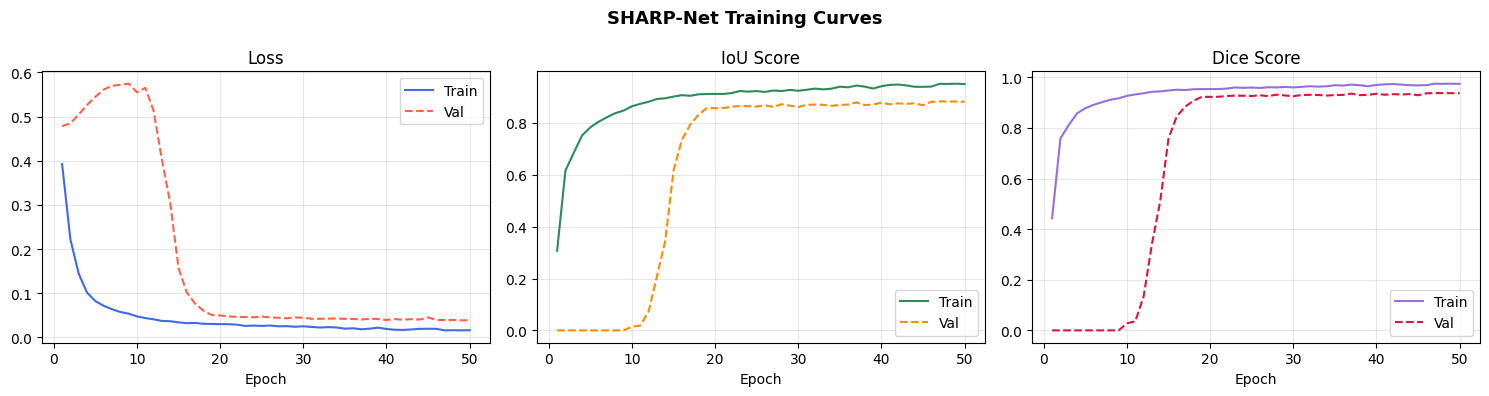

Best epoch: 47  |  Val IoU: 0.8830  |  Val Dice: 0.9378


In [9]:
# ============================================================
# CELL 9: Plot training history
# ============================================================
h = hist.history
ep = range(1, len(h['loss'])+1)

fig, axs = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('SHARP-Net Training Curves', fontsize=13, fontweight='bold')

axs[0].plot(ep,h['loss'],'royalblue',label='Train')
axs[0].plot(ep,h['val_loss'],'tomato',ls='--',label='Val')
axs[0].set_title('Loss'); axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(ep,h['iou_score'],'seagreen',label='Train')
axs[1].plot(ep,h['val_iou_score'],'darkorange',ls='--',label='Val')
axs[1].set_title('IoU Score'); axs[1].legend(); axs[1].grid(alpha=0.3)

axs[2].plot(ep,h['dice_score'],'mediumpurple',label='Train')
axs[2].plot(ep,h['val_dice_score'],'crimson',ls='--',label='Val')
axs[2].set_title('Dice Score'); axs[2].legend(); axs[2].grid(alpha=0.3)

for ax in axs: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

bi = np.argmax(h['val_iou_score'])
print(f'Best epoch: {bi+1}  |  Val IoU: {h["val_iou_score"][bi]:.4f}  |  Val Dice: {h["val_dice_score"][bi]:.4f}')

## 🧪 Cell 10: Evaluate + Visualise Test Set

✅ Loaded best weights: /content/checkpoints/sharpnet_best.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - dice_score: 0.9098 - iou_score: 0.8409 - loss: 0.0562

📊 Test Results → Loss:0.0562  IoU:84.1%  Dice:91.0%
   Pixel Accuracy: 99.40%


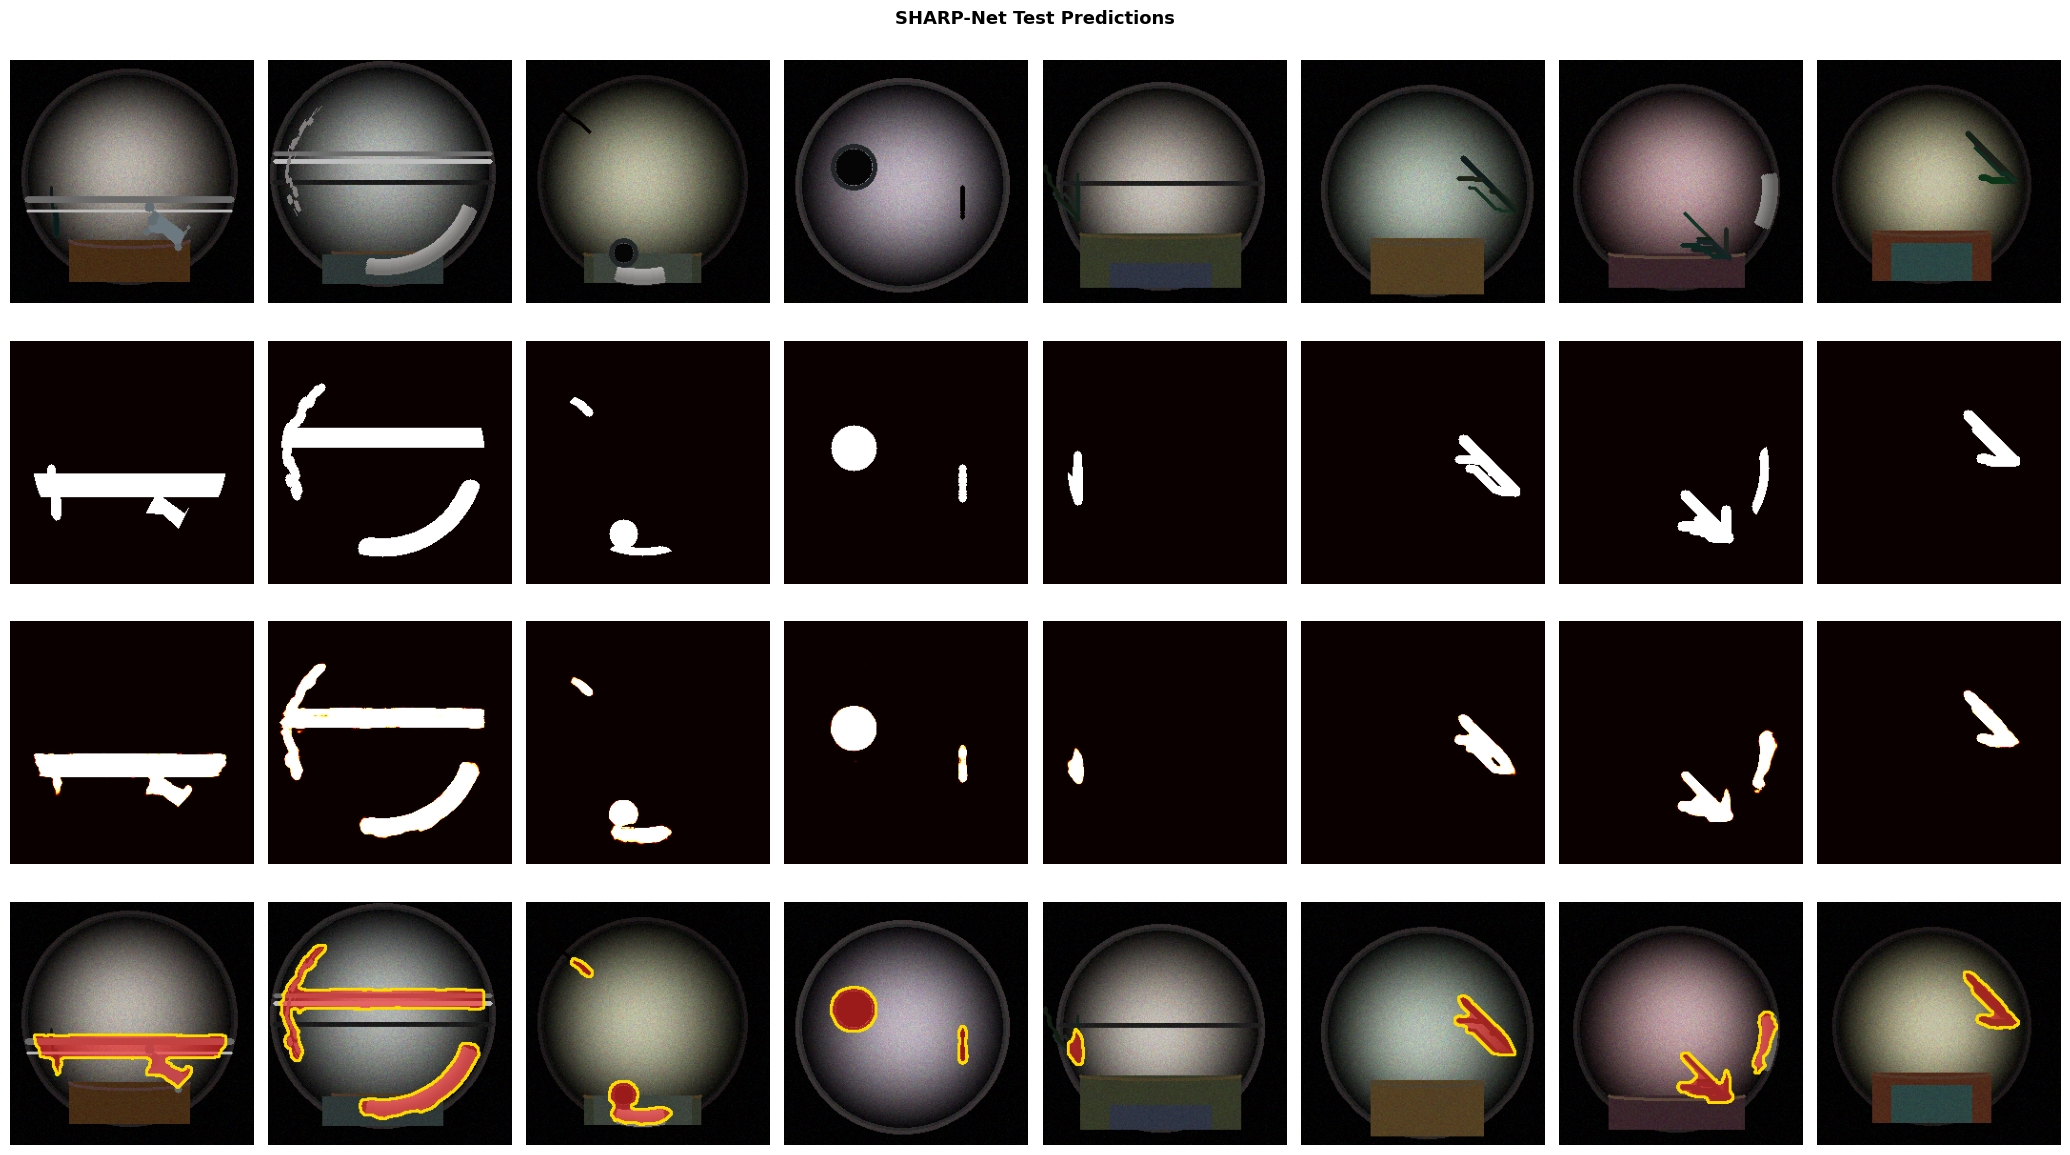

In [10]:
# ============================================================
# CELL 10: Load best weights, evaluate, visualise
# ============================================================
model.load_weights(CKPT)
print(f'✅ Loaded best weights: {CKPT}')

loss, iou, dice = model.evaluate(test_ds, verbose=1)
print(f'\n📊 Test Results → Loss:{loss:.4f}  IoU:{iou*100:.1f}%  Dice:{dice*100:.1f}%')

# ── Pixel accuracy ─────────────────────────────────────────
all_p, all_g = [], []
for xb, yb in test_ds:
    p = model.predict(xb, verbose=0)[0,:,:,0]
    all_p.append((p>0.35).astype(np.uint8))
    all_g.append(yb[0,:,:,0].numpy().astype(np.uint8))
acc = np.mean(np.concatenate([p.ravel() for p in all_p]) ==
              np.concatenate([g.ravel() for g in all_g]))
print(f'   Pixel Accuracy: {acc*100:.2f}%')

# ── Visual predictions ─────────────────────────────────────
n_show = min(8, len(te_i))
chosen = random.sample(list(zip(te_i, te_m)), n_show)

fig, axes = plt.subplots(4, n_show, figsize=(n_show*2.6, 12))
fig.suptitle('SHARP-Net Test Predictions', fontsize=13, fontweight='bold')

for col, (ip, mp) in enumerate(chosen):
    img  = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (IMG_W, IMG_H))
    gt   = cv2.resize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE), (IMG_W, IMG_H))
    gt_b = (gt > 127).astype(np.uint8)

    inp_t = img.astype(np.float32)/255.0
    prob  = model.predict(inp_t[None], verbose=0)[0,:,:,0]
    pred  = (prob > 0.35).astype(np.uint8)

    # Morphological clean-up
    k     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    pred  = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, k)

    overlay = img.copy().astype(np.float32)
    dp = pred > 0
    overlay[dp] = overlay[dp]*0.4 + np.array([255,40,40])*0.6
    overlay = overlay.astype(np.uint8)
    cnts, _ = cv2.findContours(pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cnts, -1, (255,220,0), 2)

    axes[0,col].imshow(img);              axes[0,col].axis('off')
    axes[1,col].imshow(gt_b,  cmap='hot',vmin=0,vmax=1); axes[1,col].axis('off')
    axes[2,col].imshow(prob,  cmap='hot',vmin=0,vmax=1); axes[2,col].axis('off')
    axes[3,col].imshow(overlay);          axes[3,col].axis('off')

for r,lbl in enumerate(['Original','Ground Truth','Prob Map','🔴 Detected']):
    axes[r,0].set_ylabel(lbl, fontsize=9, fontweight='bold', rotation=0, ha='right')

plt.tight_layout()
plt.savefig('/content/test_predictions.png', dpi=130, bbox_inches='tight')
plt.show()

## 📤 Cell 11: Inference on Your Own Sewer/Culvert Image
Upload any real or synthetic sewer/culvert pipe photo — SHARP-Net will highlight defects.

📁 Upload a sewer or culvert pipe image (JPG/PNG/WEBP) ...


Saving pipe.webp to pipe.webp

🖼  Uploaded: pipe.webp


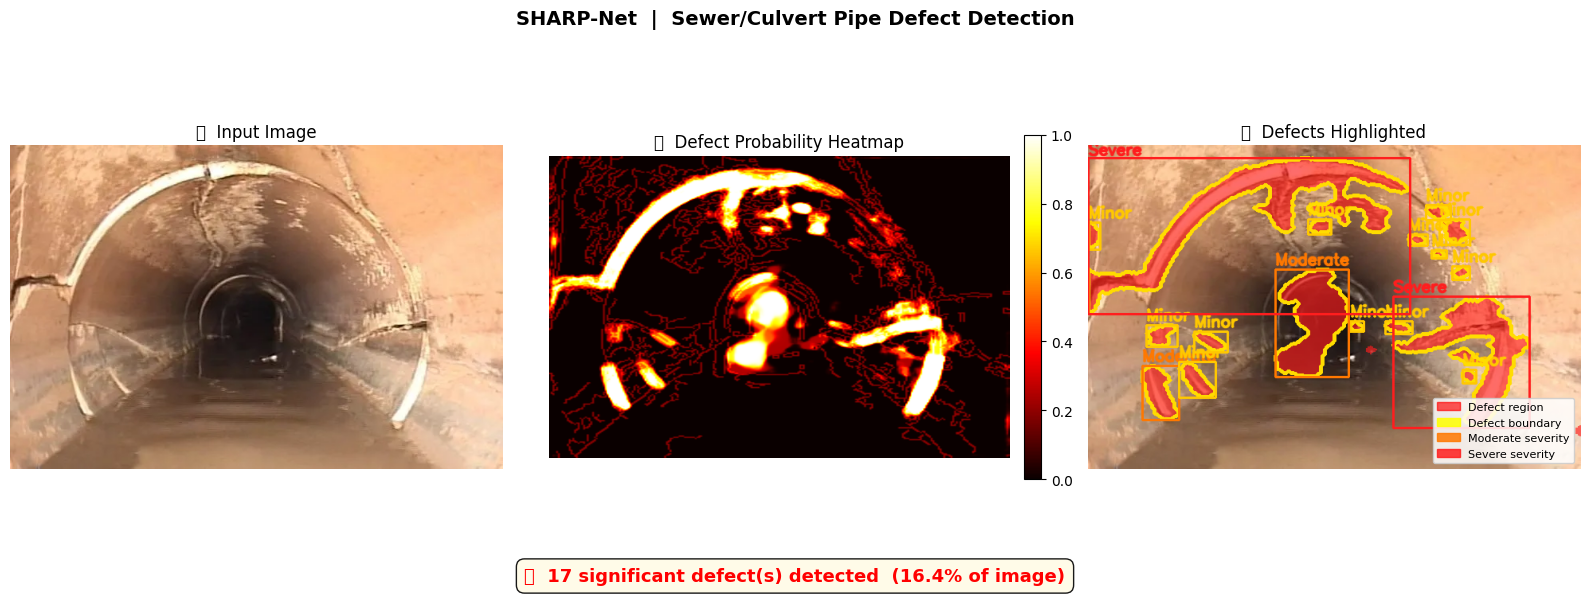


🚨  17 significant defect(s) detected  (16.4% of image)
Threshold used: 0.3  |  TTA: True
Defects found (contours >76px²): 17

📁 Result saved → /content/inference_result.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ============================================================
# CELL 11: INFERENCE — upload a real sewer/culvert image
#
# Improvements vs v1:
#  ✅ Lower threshold (0.30) — more sensitive to subtle defects
#  ✅ Test-time augmentation (TTA) — averages 4 flipped predictions
#  ✅ Edge-map fusion — uses Canny to reinforce thin cracks
#  ✅ Morphological refinement — cleans noise, connects fragments
#  ✅ Per-defect bounding boxes with severity labels
#  ✅ Results in original image resolution
# ============================================================
from google.colab import files as cf

THRESHOLD = 0.30   # Lower = more sensitive (catches subtle defects)
TTA       = True   # Test-time augmentation

def tta_predict(model, img_norm, thr=THRESHOLD):
    """
    Test-Time Augmentation: average predictions over
    4 orientations (original, hflip, vflip, both flips).
    Greatly improves detection on real-world images.
    """
    preds = []
    for do_hflip in [False, True]:
        for do_vflip in [False, True]:
            x = img_norm.copy()
            if do_hflip: x = x[:,::-1,:]
            if do_vflip: x = x[::-1,:,:]
            p = model.predict(x[None], verbose=0)[0,:,:,0]
            if do_hflip: p = p[:,::-1]
            if do_vflip: p = p[::-1,:]
            preds.append(p)
    return np.mean(preds, axis=0)

def enhance_with_edges(prob_map, img_gray, weight=0.25):
    """
    Fuse network probability map with Canny edge map.
    Helps recover thin cracks the network might miss.
    """
    blur  = cv2.GaussianBlur(img_gray, (3,3), 0)
    edges = cv2.Canny(blur, 30, 90).astype(np.float32) / 255.0
    return np.clip(prob_map + weight * edges, 0, 1)

def get_severity(area_pct):
    if area_pct < 0.5:  return 'Minor',   (255,200,0)
    if area_pct < 3.0:  return 'Moderate',(255,120,0)
    return 'Severe', (255,30,30)

print('📁 Upload a sewer or culvert pipe image (JPG/PNG/WEBP) ...')
uploaded = cf.upload()

if uploaded:
    fpath = list(uploaded.keys())[0]
    print(f'\n🖼  Uploaded: {fpath}')

    # ── Load image ──────────────────────────────────────
    raw = cv2.imdecode(
        np.frombuffer(uploaded[fpath], dtype=np.uint8), cv2.IMREAD_COLOR
    )
    if raw is None:
        from PIL import Image as PILImage
        pil = PILImage.open(fpath).convert('RGB')
        raw = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    img_orig  = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    H0, W0    = img_orig.shape[:2]

    # ── Resize to model input ──────────────────────────
    img_res   = cv2.resize(img_orig, (IMG_W, IMG_H))
    img_norm  = img_res.astype(np.float32) / 255.0
    gray_res  = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)

    # ── Inference (with TTA) ───────────────────────────
    if TTA:
        prob = tta_predict(model, img_norm, THRESHOLD)
    else:
        prob = model.predict(img_norm[None], verbose=0)[0,:,:,0]

    # ── Fuse with edge map ─────────────────────────────
    prob = enhance_with_edges(prob, gray_res, weight=0.20)

    # ── Threshold + morphological refinement ──────────
    mask = (prob > THRESHOLD).astype(np.uint8)
    k3   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    k1   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k3)   # bridge gaps
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k1)   # remove speckle
    mask = cv2.dilate(mask, k1, iterations=1)             # slightly expand

    # ── Rescale back to original resolution ───────────
    prob_up = cv2.resize(prob, (W0,H0))
    mask_up = cv2.resize(mask, (W0,H0), interpolation=cv2.INTER_NEAREST)

    # ── Build highlighted overlay ──────────────────────
    overlay = img_orig.copy().astype(np.float32)
    dp      = mask_up > 0
    overlay[dp] = overlay[dp]*0.35 + np.array([255,30,30],np.float32)*0.65
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # ── Per-defect contours + bounding boxes ──────────
    cnts, _ = cv2.findContours(
        mask_up.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    # Filter tiny noise contours
    min_area = (W0 * H0) * 0.0003
    cnts_big = [c for c in cnts if cv2.contourArea(c) > min_area]

    for cnt in cnts_big:
        area_pct = cv2.contourArea(cnt) / (W0*H0) * 100
        sev_lbl, sev_col = get_severity(area_pct)
        cv2.drawContours(overlay, [cnt], -1, (255,220,0), 3)
        x,y,bw,bh = cv2.boundingRect(cnt)
        cv2.rectangle(overlay, (x,y), (x+bw,y+bh), sev_col, 2)
        cv2.putText(overlay, sev_lbl, (x, max(y-6,12)),
                    cv2.FONT_HERSHEY_SIMPLEX, max(0.4, min(0.65, W0/800)),
                    sev_col, 2, cv2.LINE_AA)

    # ── Status ─────────────────────────────────────────
    defect_pct = mask_up.mean()*100
    n_defects  = len(cnts_big)

    if n_defects == 0 or defect_pct < 0.3:
        status     = '✅  No significant defects detected'
        status_col = 'green'
    elif defect_pct < 3.0:
        status     = f'⚠️  {n_defects} minor defect(s) detected  ({defect_pct:.1f}% of image)'
        status_col = 'darkorange'
    else:
        status     = f'🚨  {n_defects} significant defect(s) detected  ({defect_pct:.1f}% of image)'
        status_col = 'red'

    # ── Plot ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
    fig.suptitle('SHARP-Net  |  Sewer/Culvert Pipe Defect Detection',
                 fontsize=14, fontweight='bold', y=1.01)

    axes[0].imshow(img_orig)
    axes[0].set_title('📷  Input Image', fontsize=12)
    axes[0].axis('off')

    im = axes[1].imshow(prob_up, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('🌡️  Defect Probability Heatmap', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.035, pad=0.03)

    axes[2].imshow(overlay)
    axes[2].set_title('🔴  Defects Highlighted', fontsize=12)
    axes[2].axis('off')

    # Legend
    handles = [
        mpatches.Patch(color='red',    alpha=0.65, label='Defect region'),
        mpatches.Patch(color='yellow', alpha=0.85, label='Defect boundary'),
        mpatches.Patch(color='#ff7800',alpha=0.85, label='Moderate severity'),
        mpatches.Patch(color='#ff1e1e',alpha=0.85, label='Severe severity'),
    ]
    axes[2].legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.85)

    fig.text(0.5, -0.03, status, ha='center', fontsize=13,
             fontweight='bold', color=status_col,
             bbox=dict(boxstyle='round,pad=0.45', facecolor='#fffbe6', alpha=0.9))

    plt.tight_layout()
    OUT = '/content/inference_result.png'
    plt.savefig(OUT, dpi=160, bbox_inches='tight')
    plt.show()

    print(f'\n{status}')
    print(f'Threshold used: {THRESHOLD}  |  TTA: {TTA}')
    print(f'Defects found (contours >{min_area:.0f}px²): {n_defects}')
    print(f'\n📁 Result saved → {OUT}')
    cf.download(OUT)
else:
    print('⚠️  No file uploaded.')

## 💾 Cell 12: Save & Download Model

In [15]:
# ============================================================
# CELL 12: Save model weights
# ============================================================
from google.colab import files as cf

model.save('/content/sharp_net_v2.keras')
model.save_weights(f'{CKPT_DIR}/sharp_net_v2_final.weights.h5')

with zipfile.ZipFile('/content/sharp_net_v2_weights.zip','w') as z:
    z.write(CKPT, 'sharpnet_best.h5')

print('✅ Model saved. Downloading weights ...')
cf.download('/content/sharp_net_v2_weights.zip')

✅ Model saved. Downloading weights ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>